In [1]:
# Cell 0: Environment setup
!pip install -q albumentations opencv-python-headless

import os, cv2, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
# Cell 1: Kaggle API authentication
from google.colab import files
print("Upload your kaggle.json file now:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

Upload your kaggle.json file now:


Saving kaggle.json to kaggle.json


In [3]:
# Cell 2: Download the glaucoma multi-dataset mirror (G1020 + ORIGA + REFUGE)
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [04:31<00:00, 22.0MB/s]



In [4]:
# Cell 3: Confirm folder structure
!find /content/data/G1020 -maxdepth 3 -type d | sort

/content/data/G1020
/content/data/G1020/Images
/content/data/G1020/Images_Cropped
/content/data/G1020/Images_Cropped/img
/content/data/G1020/Images_Square
/content/data/G1020/Masks
/content/data/G1020/Masks_Cropped
/content/data/G1020/Masks_Cropped/img
/content/data/G1020/Masks_Square
/content/data/G1020/NerveRemoved_Images


In [5]:
# Cell 4: G1020 paths + mask inspection
G1020_IMG_DIR = "/content/data/G1020/Images_Cropped/img"
G1020_MASK_DIR = "/content/data/G1020/Masks_Cropped/img"

sample_files = sorted(os.listdir(G1020_MASK_DIR))[:5]
print("Sample mask files:", sample_files)
for f in sample_files:
    m = cv2.imread(os.path.join(G1020_MASK_DIR, f), cv2.IMREAD_UNCHANGED)
    print(f, "-> shape:", m.shape, "unique values:", np.unique(m))

Sample mask files: ['image_0.png', 'image_1.png', 'image_10.png', 'image_1000.png', 'image_1001.png']
image_0.png -> shape: (480, 480) unique values: [0 1 2]
image_1.png -> shape: (471, 471) unique values: [0 1 2]
image_10.png -> shape: (490, 490) unique values: [0 1]
image_1000.png -> shape: (442, 442) unique values: [0 1 2]
image_1001.png -> shape: (380, 373) unique values: [0 1 2]


In [6]:
# Cell 5: Train/val/test split
random.seed(42)
all_files = sorted(os.listdir(G1020_IMG_DIR))
matched = [f for f in all_files if os.path.exists(os.path.join(G1020_MASK_DIR, os.path.splitext(f)[0] + ".png"))]

random.shuffle(matched)
n = len(matched)
n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_files = matched[:n_train]
val_files = matched[n_train:n_train+n_val]
test_files = matched[n_train+n_val:]

print(f"Total: {n} | Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Total: 1020 | Train: 816 | Val: 102 | Test: 102


In [8]:
# Cell 6: Albumentations transforms
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [10]:
# Cell 7: Dataset class for a manual file-list split
class GlaucomaDataset(Dataset):
    def __init__(self, img_dir, mask_dir, file_list, transform=None):
        self.img_dir, self.mask_dir, self.transform = img_dir, mask_dir, transform
        self.filenames = []
        for f in file_list:
            mask_name = os.path.splitext(f)[0] + ".png"
            if os.path.exists(os.path.join(mask_dir, mask_name)):
                self.filenames.append((f, mask_name))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name, mask_name = self.filenames[idx]
        image = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_UNCHANGED)
        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask']
        return image, mask.long()

In [11]:
# Cell 8: DataLoaders
NUM_CLASSES = 3   # <-- SET BASED ON CELL 4 OUTPUT: 3 if unique values are [0,1,2], 2 if only [0,1]

train_ds = GlaucomaDataset(G1020_IMG_DIR, G1020_MASK_DIR, train_files, transform=train_transform)
val_ds   = GlaucomaDataset(G1020_IMG_DIR, G1020_MASK_DIR, val_files,   transform=val_transform)
test_ds  = GlaucomaDataset(G1020_IMG_DIR, G1020_MASK_DIR, test_files,  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))
imgs, masks = next(iter(train_loader))
print("Batch shapes:", imgs.shape, masks.shape, "| mask unique:", torch.unique(masks))

Train: 816 Val: 102 Test: 102
Batch shapes: torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256]) | mask unique: tensor([0, 1, 2])


In [12]:
# Cell 9: KANLinear - the core KAN layer, built from scratch
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 base_activation=nn.SiLU, grid_range=(-1, 1)):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        grid = grid.expand(in_features, -1).contiguous()
        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.empty(out_features, in_features, grid_size + spline_order)
        )
        self.base_activation = base_activation()

        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        nn.init.normal_(self.spline_weight, mean=0.0, std=0.1)

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()
        for k in range(1, self.spline_order + 1):
            left  = (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)])
            right = (grid[:, k + 1 :] - x) / (grid[:, k + 1 :] - grid[:, 1:-k])
            bases = left * bases[:, :, :-1] + right * bases[:, :, 1:]
        return bases

    def forward(self, x):
        orig_shape = x.shape
        x = x.reshape(-1, self.in_features)
        base_out = F.linear(self.base_activation(x), self.base_weight)
        spline_basis = self.b_splines(x)
        spline_out = torch.einsum("bik,oik->bo", spline_basis, self.spline_weight)
        out = base_out + spline_out
        return out.reshape(*orig_shape[:-1], self.out_features)

In [13]:
# Cell 10: DWConv + KANBlock
class DWConv(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class KANBlock(nn.Module):
    def __init__(self, dim, hidden_dim=None, grid_size=5, spline_order=3, drop=0.0):
        super().__init__()
        hidden_dim = hidden_dim or dim
        self.norm = nn.LayerNorm(dim)
        self.fc1 = KANLinear(dim, hidden_dim, grid_size=grid_size, spline_order=spline_order)
        self.dwconv = DWConv(hidden_dim)
        self.act = nn.GELU()
        self.fc2 = KANLinear(hidden_dim, dim, grid_size=grid_size, spline_order=spline_order)
        self.drop = nn.Dropout(drop)

    def forward(self, x, H, W):
        shortcut = x
        x = self.norm(x)
        x = self.fc1(x)
        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x + shortcut

In [14]:
# Cell 11: ConvBlock, PatchEmbed, tokens_to_map, UpConv
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class PatchEmbed(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.norm = nn.LayerNorm(out_ch)
    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x, H, W


def tokens_to_map(x, H, W):
    B, N, C = x.shape
    return x.transpose(1, 2).reshape(B, C, H, W)


class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
    def forward(self, x):
        x = self.up(x)
        return self.conv(x)

In [15]:
# Cell 12: U-KAN model (same architecture as REFUGE run)
class UKAN(nn.Module):
    def __init__(self, num_classes=3, in_ch=3,
                 conv_channels=(64, 128, 256), tok_channels=(320, 512),
                 grid_size=5, spline_order=3):
        super().__init__()
        C1, C2, C3 = conv_channels
        D1, D2 = tok_channels

        self.conv1 = ConvBlock(in_ch, C1)
        self.conv2 = ConvBlock(C1, C2)
        self.conv3 = ConvBlock(C2, C3)
        self.pool = nn.MaxPool2d(2)

        self.patch_embed1 = PatchEmbed(C3, D1, stride=2)
        self.kan_enc1 = KANBlock(D1, grid_size=grid_size, spline_order=spline_order)
        self.patch_embed2 = PatchEmbed(D1, D2, stride=2)
        self.kan_enc2 = KANBlock(D2, grid_size=grid_size, spline_order=spline_order)

        self.up_tok1 = UpConv(D2, D1)
        self.kan_dec1 = KANBlock(D1, grid_size=grid_size, spline_order=spline_order)
        self.up_tok2 = UpConv(D1, C3)
        self.kan_dec2 = KANBlock(C3, grid_size=grid_size, spline_order=spline_order)

        self.up_conv1 = UpConv(C3, C3)
        self.dconv1 = ConvBlock(C3, C2)
        self.up_conv2 = UpConv(C2, C2)
        self.dconv2 = ConvBlock(C2, C1)
        self.up_conv3 = UpConv(C1, C1)
        self.dconv3 = ConvBlock(C1, C1)

        self.head = nn.Conv2d(C1, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.conv1(x); p1 = self.pool(e1)
        e2 = self.conv2(p1); p2 = self.pool(e2)
        e3 = self.conv3(p2); p3 = self.pool(e3)

        t1, H1, W1 = self.patch_embed1(p3)
        t1 = self.kan_enc1(t1, H1, W1)
        skip_tok1 = tokens_to_map(t1, H1, W1)

        t2, H2, W2 = self.patch_embed2(skip_tok1)
        t2 = self.kan_enc2(t2, H2, W2)
        b = tokens_to_map(t2, H2, W2)

        d_t1 = self.up_tok1(b) + skip_tok1
        B_, C_, H_, W_ = d_t1.shape
        d_t1 = tokens_to_map(self.kan_dec1(d_t1.flatten(2).transpose(1, 2), H_, W_), H_, W_)

        d_t2 = self.up_tok2(d_t1) + p3
        B_, C_, H_, W_ = d_t2.shape
        d_t2 = tokens_to_map(self.kan_dec2(d_t2.flatten(2).transpose(1, 2), H_, W_), H_, W_)

        d1 = self.dconv1(self.up_conv1(d_t2) + e3)
        d2 = self.dconv2(self.up_conv2(d1) + e2)
        d3 = self.dconv3(self.up_conv3(d2) + e1)

        return self.head(d3)

In [17]:
# Cell 13: Forward pass sanity test
model = UKAN(num_classes=NUM_CLASSES).to(DEVICE)
dummy = torch.randn(4, 3, 256, 256).to(DEVICE)
out = model(dummy)
print("Output shape:", out.shape)
print("Total trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Output shape: torch.Size([4, 3, 256, 256])
Total trainable parameters: 16578499


In [18]:

# Cell 14: Dice + Combined loss
class DiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6):
        super().__init__()
        self.num_classes, self.smooth = num_classes, smooth
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_onehot, dims)
        union = torch.sum(probs + targets_onehot, dims)
        dice_per_class = (2.*intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_per_class.mean()

class CombinedLoss(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)
    def forward(self, logits, targets):
        return 0.5*self.ce(logits, targets) + 0.5*self.dice(logits, targets)

In [19]:
# Cell 15: Complete metrics
@torch.no_grad()
def compute_all_metrics(logits, targets, num_classes, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)
    metrics = {"dice": [], "iou": [], "precision": [], "recall": [], "f1": []}
    for c in range(num_classes):
        pred_c, target_c = (preds == c), (targets == c)
        tp = (pred_c & target_c).sum().float()
        fp = (pred_c & ~target_c).sum().float()
        fn = (~pred_c & target_c).sum().float()
        dice = (2*tp + smooth) / (2*tp + fp + fn + smooth)
        iou = (tp + smooth) / (tp + fp + fn + smooth)
        precision = (tp + smooth) / (tp + fp + smooth)
        recall = (tp + smooth) / (tp + fn + smooth)
        f1 = (2*precision*recall) / (precision + recall + smooth)
        metrics["dice"].append(dice.item()); metrics["iou"].append(iou.item())
        metrics["precision"].append(precision.item()); metrics["recall"].append(recall.item())
        metrics["f1"].append(f1.item())
    metrics["accuracy"] = (preds == targets).float().mean().item()
    return metrics

In [21]:
# Cell 16: Training loop with complete metric tracking
def evaluate_full(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    agg = {k: np.zeros(num_classes) for k in ["dice","iou","precision","recall","f1"]}
    agg["accuracy"] = 0.0
    n_batches = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            running_loss += criterion(outputs, masks).item() * images.size(0)
            m = compute_all_metrics(outputs, masks, num_classes)
            for k in ["dice","iou","precision","recall","f1"]:
                agg[k] += np.array(m[k])
            agg["accuracy"] += m["accuracy"]
            n_batches += 1
    for k in ["dice","iou","precision","recall","f1"]:
        agg[k] /= n_batches
    agg["accuracy"] /= n_batches
    return running_loss / len(loader.dataset), agg


def train_model_full(model, train_loader, val_loader, num_classes, num_epochs=100, patience=15, lr=1e-3, save_path="/content/best_model.pth"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = CombinedLoss(num_classes=num_classes)

    best_mean_dice, epochs_no_improve = 0.0, 0
    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    for k in ["dice","iou","precision","recall","f1"]:
        for c in range(num_classes):
            history[f"val_{k}_class{c}"] = []

    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        val_loss, agg = evaluate_full(model, val_loader, criterion, DEVICE, num_classes)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(agg["accuracy"])
        for k in ["dice","iou","precision","recall","f1"]:
            for c in range(num_classes):
                history[f"val_{k}_class{c}"].append(agg[k][c])

        mean_dice = np.mean(agg["dice"][1:]) if num_classes > 1 else agg["dice"][0]
        print(f"Epoch {epoch:3d}/{num_epochs} | TrainLoss:{train_loss:.4f} | ValLoss:{val_loss:.4f} | "
              f"Acc:{agg['accuracy']:.4f} | Dice:{np.round(agg['dice'],3)} | IoU:{np.round(agg['iou'],3)} | MeanDice(fg):{mean_dice:.4f}")

        if mean_dice > best_mean_dice:
            best_mean_dice, epochs_no_improve = mean_dice, 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> New best saved ({best_mean_dice:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
    return history

In [22]:
# Cell 17: Train on G1020
model_g1020 = UKAN(num_classes=NUM_CLASSES).to(DEVICE)
history_g1020 = train_model_full(model_g1020, train_loader, val_loader,
                                   num_classes=NUM_CLASSES, save_path="/content/best_ukan_g1020.pth")

Epoch   1/100 | TrainLoss:0.4292 | ValLoss:0.5876 | Acc:0.7205 | Dice:[0.752 0.754 0.584] | IoU:[0.602 0.605 0.414] | MeanDice(fg):0.6689
  -> New best saved (0.6689)
Epoch   2/100 | TrainLoss:0.3482 | ValLoss:0.5702 | Acc:0.7181 | Dice:[0.737 0.754 0.587] | IoU:[0.584 0.605 0.417] | MeanDice(fg):0.6703
  -> New best saved (0.6703)
Epoch   3/100 | TrainLoss:0.3344 | ValLoss:0.4540 | Acc:0.7537 | Dice:[0.733 0.792 0.644] | IoU:[0.579 0.657 0.477] | MeanDice(fg):0.7184
  -> New best saved (0.7184)
Epoch   4/100 | TrainLoss:0.3190 | ValLoss:0.8369 | Acc:0.6240 | Dice:[0.679 0.639 0.132] | IoU:[0.515 0.47  0.072] | MeanDice(fg):0.3854
Epoch   5/100 | TrainLoss:0.3082 | ValLoss:0.3130 | Acc:0.8451 | Dice:[0.778 0.879 0.792] | IoU:[0.638 0.784 0.658] | MeanDice(fg):0.8355
  -> New best saved (0.8355)
Epoch   6/100 | TrainLoss:0.3020 | ValLoss:0.2826 | Acc:0.8586 | Dice:[0.846 0.882 0.772] | IoU:[0.735 0.789 0.631] | MeanDice(fg):0.8273
Epoch   7/100 | TrainLoss:0.2929 | ValLoss:0.3220 | Acc:

In [23]:
# Cell 18: Test evaluation
best_model = UKAN(num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load("/content/best_ukan_g1020.pth"))

test_loss, test_metrics = evaluate_full(best_model, test_loader, CombinedLoss(NUM_CLASSES), DEVICE, NUM_CLASSES)
print("Test Loss:", test_loss)
for k in ["accuracy","dice","iou","precision","recall","f1"]:
    print(f"Test {k}:", test_metrics[k])

Test Loss: 0.18947762572297863
Test accuracy: 0.9095231569730319
Test dice: [0.91421551 0.92479234 0.80532408]
Test iou: [0.84296279 0.86065506 0.67796383]
Test precision: [0.91832289 0.91885516 0.82445639]
Test recall: [0.91090753 0.93101144 0.78985731]
Test f1: [0.91421502 0.92479184 0.80532359]


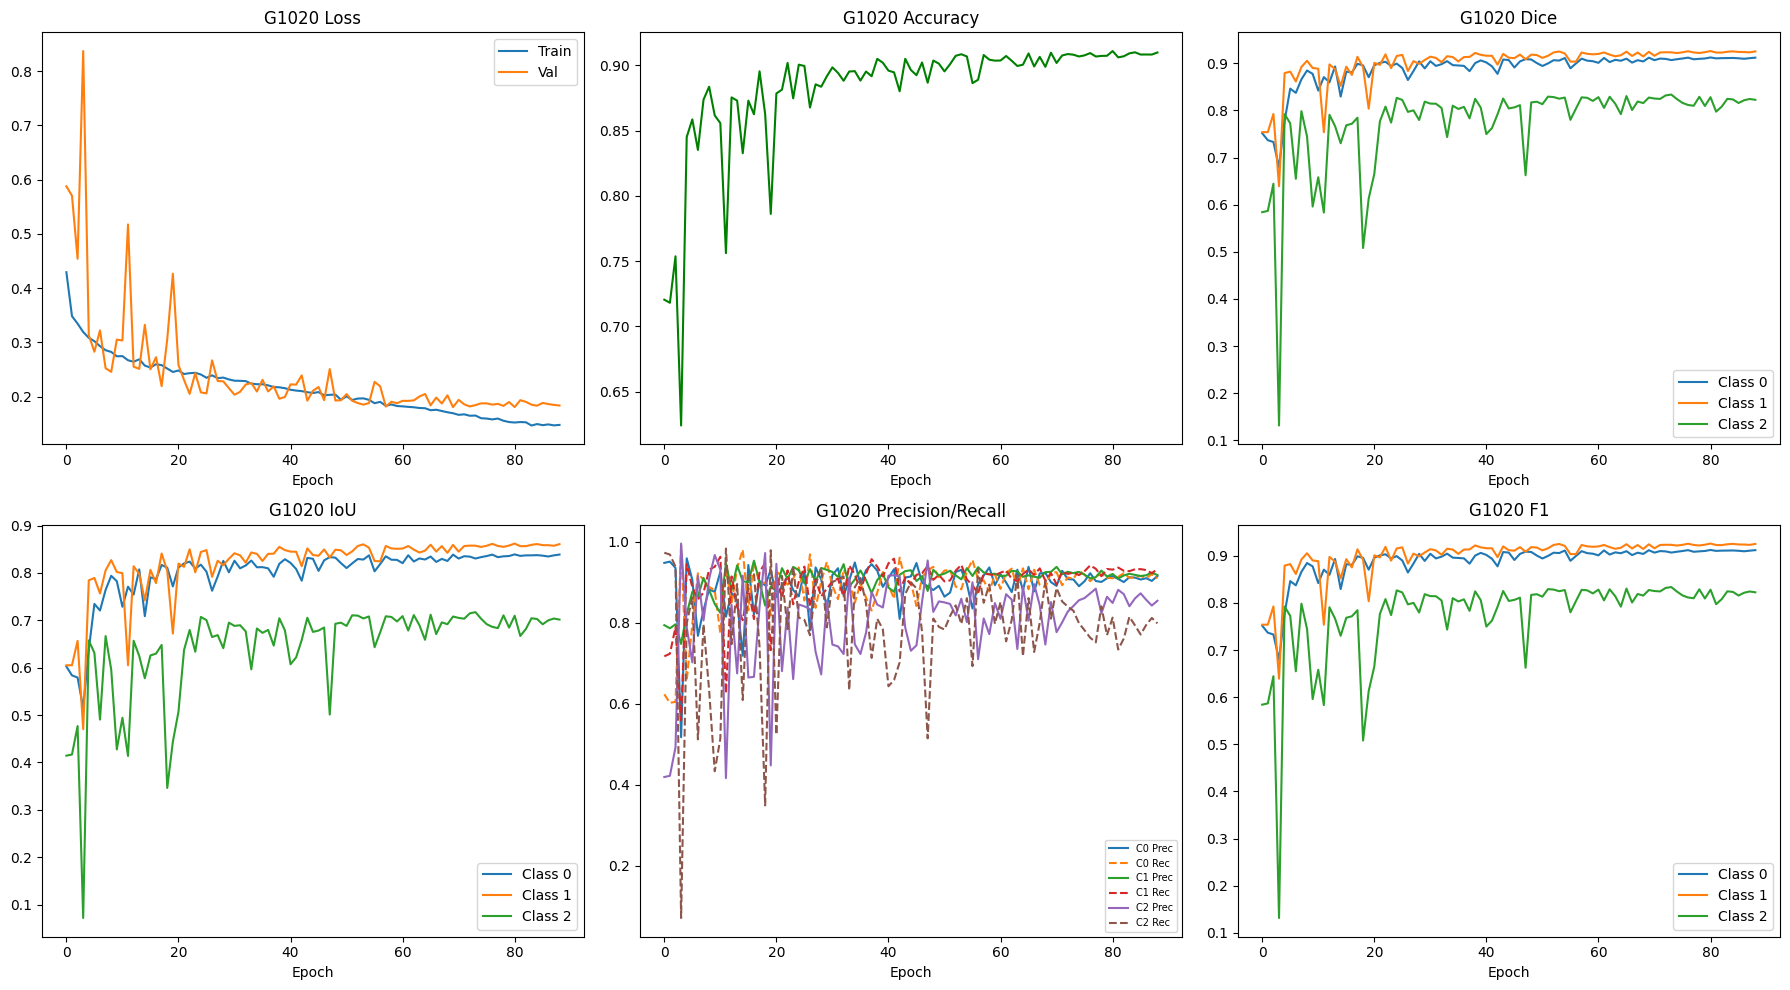

In [24]:
# Cell 19: Plot every metric curve
def plot_all_curves(history, num_classes, prefix=""):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes[0,0].plot(history["train_loss"], label="Train"); axes[0,0].plot(history["val_loss"], label="Val")
    axes[0,0].set_title(f"{prefix} Loss"); axes[0,0].set_xlabel("Epoch"); axes[0,0].legend()
    axes[0,1].plot(history["val_accuracy"], color='green'); axes[0,1].set_title(f"{prefix} Accuracy"); axes[0,1].set_xlabel("Epoch")
    for c in range(num_classes): axes[0,2].plot(history[f"val_dice_class{c}"], label=f"Class {c}")
    axes[0,2].set_title(f"{prefix} Dice"); axes[0,2].set_xlabel("Epoch"); axes[0,2].legend()
    for c in range(num_classes): axes[1,0].plot(history[f"val_iou_class{c}"], label=f"Class {c}")
    axes[1,0].set_title(f"{prefix} IoU"); axes[1,0].set_xlabel("Epoch"); axes[1,0].legend()
    for c in range(num_classes):
        axes[1,1].plot(history[f"val_precision_class{c}"], label=f"C{c} Prec")
        axes[1,1].plot(history[f"val_recall_class{c}"], '--', label=f"C{c} Rec")
    axes[1,1].set_title(f"{prefix} Precision/Recall"); axes[1,1].set_xlabel("Epoch"); axes[1,1].legend(fontsize=7)
    for c in range(num_classes): axes[1,2].plot(history[f"val_f1_class{c}"], label=f"Class {c}")
    axes[1,2].set_title(f"{prefix} F1"); axes[1,2].set_xlabel("Epoch"); axes[1,2].legend()
    plt.tight_layout(); plt.savefig(f'/content/{prefix}_curves.png', dpi=100); plt.show()

plot_all_curves(history_g1020, NUM_CLASSES, prefix="G1020")

Visualizing 5 random samples from the test set...


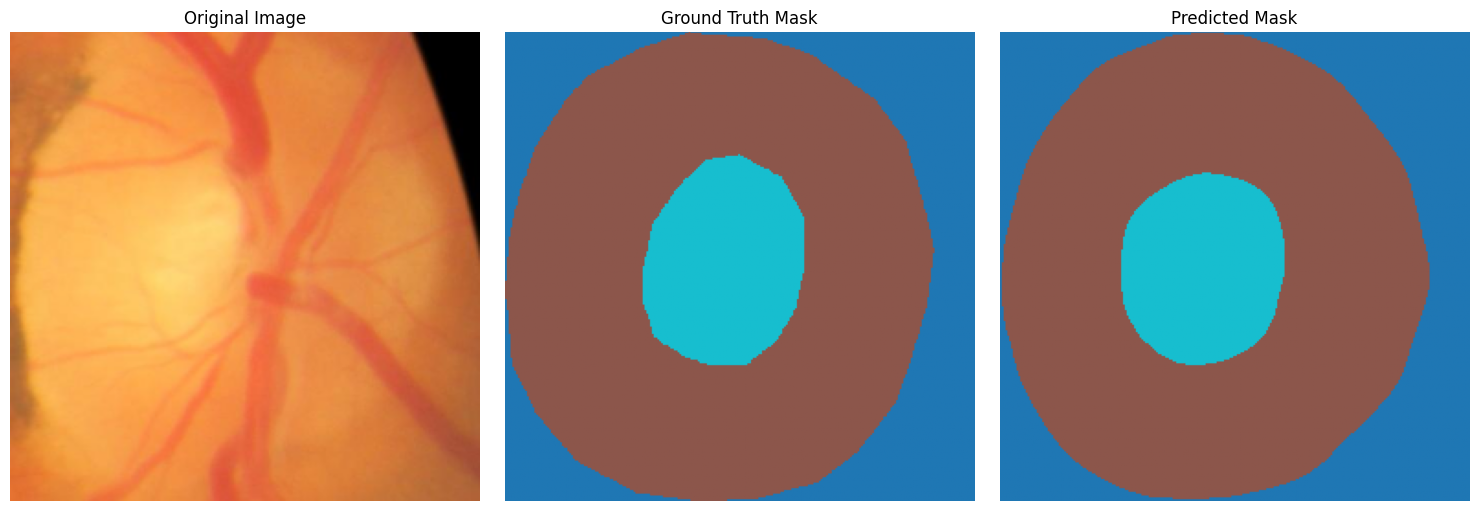

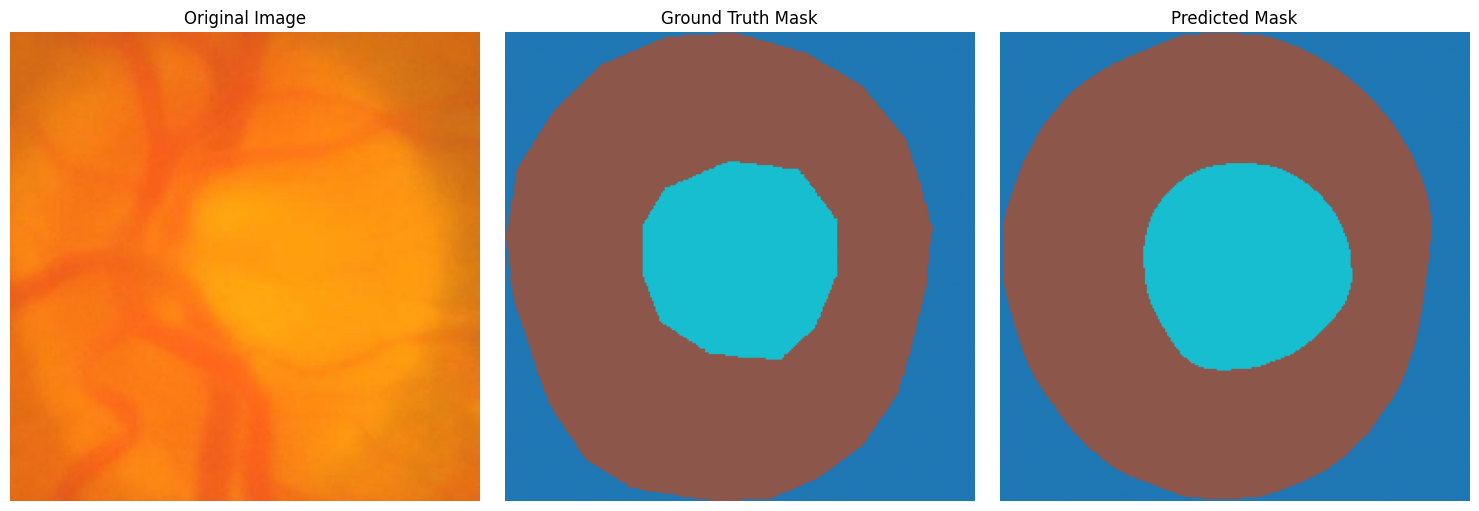

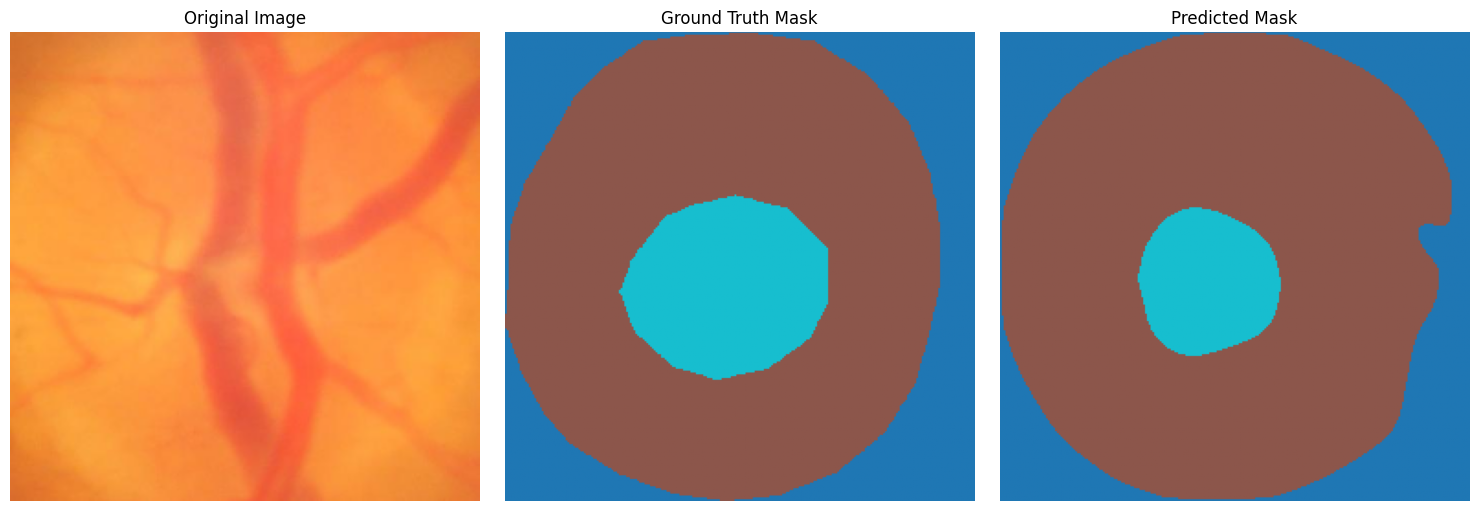

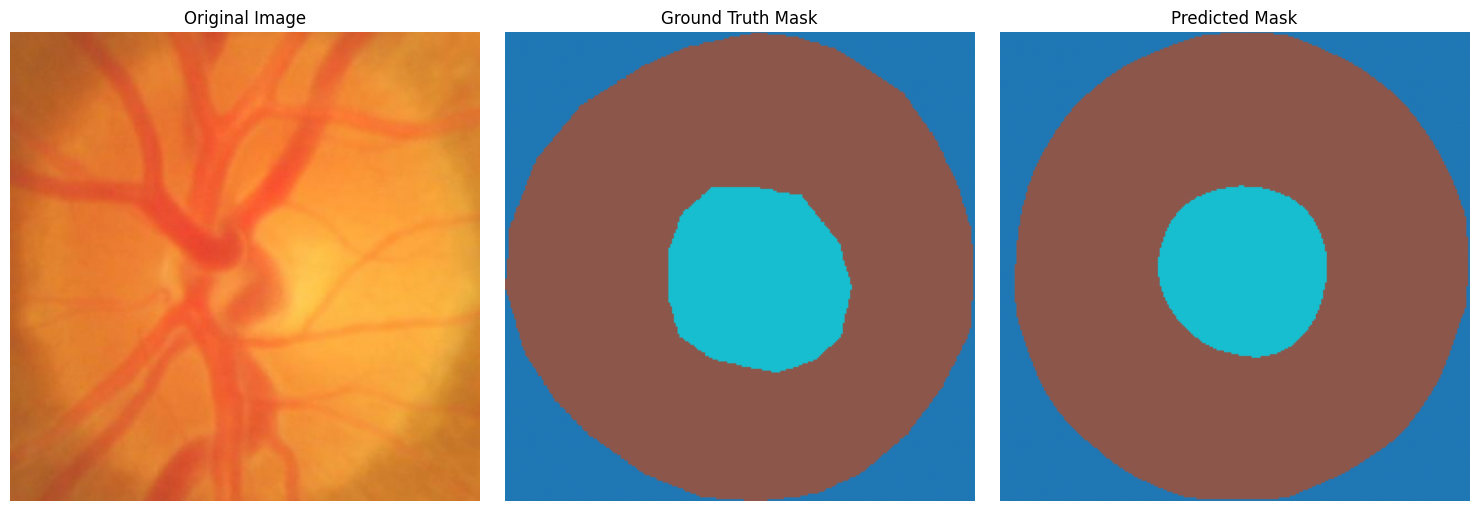

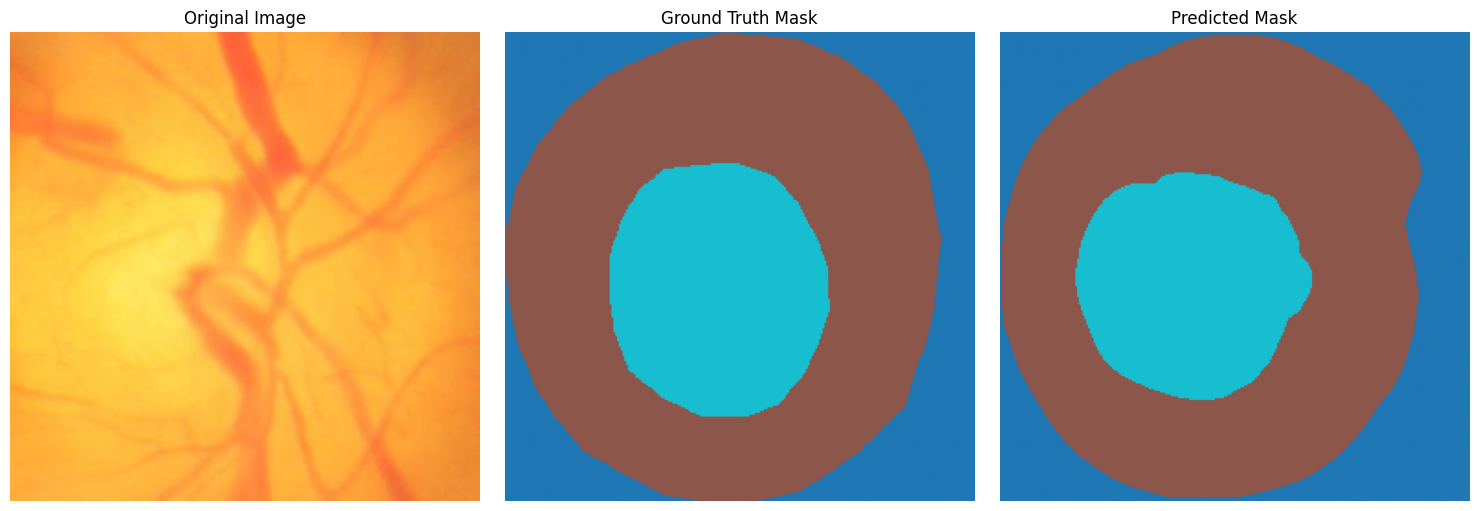

In [28]:
def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(1, 3, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(1, 3, 1, 1).to(tensor.device)
    return tensor * std + mean

def plot_segmentation_results(model, dataloader, device, num_samples=3):
    model.eval() # Set the model to evaluation mode
    samples_count = 0

    # Use a colormap for up to NUM_CLASSES distinct colors
    # We use 'tab10' which has 10 distinct colors, sufficient for NUM_CLASSES=3
    cmap = plt.colormaps.get_cmap("tab10").resampled(NUM_CLASSES)

    with torch.no_grad():
        for images, true_masks in dataloader:
            images, true_masks = images.to(device), true_masks.to(device)
            outputs = model(images)
            predicted_masks = torch.argmax(outputs, dim=1)

            for i in range(images.shape[0]):
                if samples_count >= num_samples:
                    break

                # Denormalize image for display and convert to numpy
                img_display = denormalize(images[i].cpu()).squeeze(0).permute(1, 2, 0).numpy()
                true_mask_display = true_masks[i].cpu().numpy()
                predicted_mask_display = predicted_masks[i].cpu().numpy()

                fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                # Plot original image
                axes[0].imshow(img_display)
                axes[0].set_title("Original Image")
                axes[0].axis('off')

                # Plot ground truth mask
                axes[1].imshow(true_mask_display, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
                axes[1].set_title("Ground Truth Mask")
                axes[1].axis('off')

                # Plot predicted mask
                axes[2].imshow(predicted_mask_display, cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
                axes[2].set_title("Predicted Mask")
                axes[2].axis('off')

                plt.tight_layout()
                plt.show()
                samples_count += 1
            if samples_count >= num_samples:
                break

# Assuming best_model, test_loader, DEVICE, and NUM_CLASSES are defined from previous cells
# (e.g., best_model from Cell 18, test_loader from Cell 8, DEVICE from Cell 0, NUM_CLASSES from Cell 8)

print("Visualizing 5 random samples from the test set...")
plot_segmentation_results(best_model, test_loader, DEVICE, num_samples=5)